In [1]:
from data_process import prepare
import os
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

2025-03-24 20:54:29.052543: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-24 20:54:29.063234: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-24 20:54:29.066582: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-24 20:54:29.075341: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-24 20:54:29.645424: W tensorflow/compiler/tf2

In [2]:
print(tf.__version__)

2.17.0


In [3]:
# Load the best model
model_path = os.getcwd() + '/saved_models/best_model.keras'
best_model = keras.models.load_model(model_path)
best_model.summary()

I0000 00:00:1742864071.814115 2214484 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1742864071.848372 2214484 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1742864071.851353 2214484 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1742864071.855701 2214484 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Model: "classifier_to_explain"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_2 (Resizing)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 256, 256, 1)    │       131,073 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,031,692 (49.71 MB)

 Trainable params: 4,300,131 (16.40 MB)

 Non-trainable params: 131,297 (512.88 KB)

 Optimizer params: 8,600,264 (32.81 MB)

In [4]:
labels = np.load('./dataset/labels.npy')
images = np.load('./dataset/images.npy', mmap_mode='r')
masks = np.load('./dataset/masks.npy', mmap_mode='r')
patient_ids = np.load('./dataset/patient_ids.npy').flatten()
file_paths = np.load('./dataset/file_paths.npy')
classes  = ['Meningioma Tumor', 'Glioma Tumor', 'Pituitary Tumor']

In [5]:
ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
ds = prepare(ds, shuffle=False, augment=False)

In [6]:
def get_example_by_idx(ds, i):
    """
    Return the example at index i in the dataset ds
    """
    ds_iterator = iter(ds)
    X, y = next(ds_iterator)
    while i >= X.shape[0]:
        try:
            i -= X.shape[0]
            X, y = next(ds_iterator)
        except StopIteration:
            return None
    return tf.cast(X[i], tf.float32) , y[i]
        

# Feature attribution for explaining classifier predictions

### Data Point IDs for Visualization Examples

Meningioma:
- coronal plane: 5, 431, 971
- sagittal plane: 180, 1551, 436
- axial plane: 9, 1552, 1048

Glioma Tumor:
- coronal plane: 71, 237, 737
- sagittal plane: 62, 525, 2462
- axial plane: 56, 3061, 150 
  
Pituitary Tumor:
- coronal plane: 14, 1526, 275
- sagittal plane: 92, 803, 2034
- axial plane: 1537, 499, 2404

## Saliency maps

In [7]:
def compute_saliency_map(model, ds, idx):
    """
    Return a 2D array representing gradient magnitude of each input feature of x
    w.r.t to the highest class activation for x.
    """
    image, target_onehot = get_example_by_idx(ds,idx)
    label = classes[np.argmax(target_onehot)]
    with tf.GradientTape() as tape:
        tape.watch(image)
        # expand dims to create a "batch" with a single example
        class_activations = best_model(tf.expand_dims(image, 0))
        class_activations = tf.squeeze(class_activations)
        largest_activation = class_activations[np.argmax(class_activations)]
    
    grad_x = tape.gradient(largest_activation, image).numpy()
    # bg_ind = (image.numpy() > (10 ** 2)).astype(int)
    grad_mag_x = np.abs(grad_x) # * bg_ind
    
    print(np.min(grad_mag_x), np.max(grad_mag_x), np.median(grad_mag_x))
    fig, axes = plt.subplots(1, 2)
    axes[0].tick_params(left = False, bottom = False) 
    axes[0].imshow(image, cmap='gray')
    mask = np.ma.masked_where(masks[idx] == False, masks[idx])
    # axes[0].imshow(mask, alpha=0.3, cmap='Set1')
    axes[0].set_title(f'Ground truth : {label}')
    
    axes[1].tick_params(left = False, bottom = False)
    axes[1].imshow(grad_mag_x, vmin=np.min(grad_mag_x), vmax=np.percentile(grad_mag_x, 99) , cmap='gray')
    axes[1].set_title('Saliency Map')

    # remove the x and y ticks
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    
    fig.savefig(f'figures/saliency_map_{idx}.png')
    

2025-03-24 20:54:39.249634: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
W0000 00:00:1742864079.292223 2214484 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742864079.303306 2214484 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742864079.303644 2214484 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742864079.308091 2214484 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742864079.308999 2214484 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742864079.309991 2214484 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742864079.311036 2214484 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742864079.311385 2214484 gpu_t

0.0 0.0003952992 5.7450615e-13


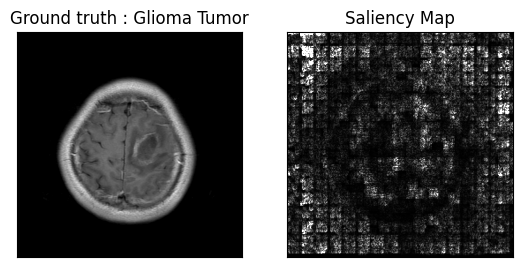

In [8]:
compute_saliency_map(best_model, ds, 150)

## Grad-CAM

In [39]:
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

def compute_gradcam(model, dataset, idx):
    """
    Compute Grad-CAM visualization of a prediction for a single data point.
    """

    image, target_onehot  = get_example_by_idx(ds,idx)
    label = classes[np.argmax(target_onehot)]
    
    last_conv_layer_name = "conv2d_3"
    last_conv_layer = model.get_layer(last_conv_layer_name)

    final_dense_layer_name = "dense_1"
    final_dense_layer = model.get_layer(final_dense_layer_name)
    final_dense_layer.activation = None

    feature_extractor = keras.models.Model(
        inputs=[model.inputs],
        outputs=[last_conv_layer.output]
    )

    with tf.GradientTape() as tape:

        input_tensor = tf.expand_dims(image, 0)
        conv_outputs = feature_extractor(input_tensor)
        
        tape.watch(conv_outputs)
        inputs = tf.keras.Input(shape=conv_outputs.shape[1:])
        
        x = inputs
        for layer in model.layers[model.layers.index(last_conv_layer) + 1:]:
            x = layer(x)
        grad_model = tf.keras.Model(inputs, x)
        predictions = grad_model(conv_outputs)
        
        predictions = predictions[0]        
        loss = predictions[tf.argmax(predictions)]

    grads = tape.gradient(loss, conv_outputs)

    grads = tf.squeeze(grads)
    conv_outputs = tf.squeeze(conv_outputs)
    
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    
    cam = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    image = image.numpy().squeeze()
    (w, h) = (image.shape[1], image.shape[0])
    heatmap = cv2.resize(cam.numpy(), (w, h))
    
    
    eps = 1e-8
    
    heatmap = (heatmap - np.min(heatmap)) / (heatmap.max() - heatmap.min() + eps)
    heatmap = (heatmap * 255).astype("uint8")
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_VIRIDIS)

    # Visualize the heatmap in on the input data point
    image = (image - np.min(image)) / (image.max() - image.min() + eps)
    image = (image * 255).astype("uint8")
    image = cv2.cvtColor(image,cv2.COLOR_GRAY2RGB)
    
    output = image * 0.5 + heatmap * 0.5
    output = (output - output.min()) / (output.max() - output.min() + eps)

    fig, axes = plt.subplots(1, 2)
    fig.tight_layout()
    axes[0].imshow(image)
    mask = np.ma.masked_where(masks[idx] == False, masks[idx])
    axes[0].imshow(mask, alpha=0.3, cmap='Set1')
    axes[0].set_title(f'Ground Truth: {label}')
    axes[1].imshow(output)   
    axes[1].set_title('Grad-CAM Heatmap')

    # remove the x and y ticks
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    fig.savefig(f'figures/gradcam_{idx}.png')
    


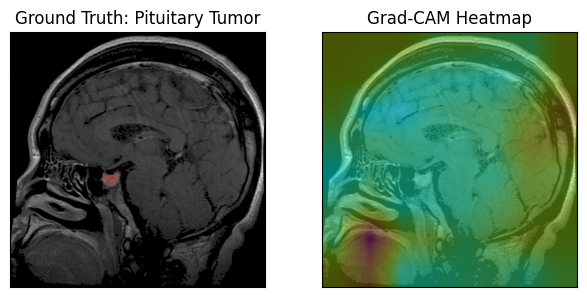

In [40]:
compute_gradcam(best_model, ds, 2034)

In [ ]:
idxs = [5, 431, 971, 180, 1551, 436, 9, 1552, 1048, 71, 237, 737, 62, 525, 2462, 56, 3061, 150, 14, 1526, 275, 92, 803, 2034, 1537, 499, 2404]

for idx in idxs:
    compute_gradcam(best_model, ds, idx)
    compute_saliency_map(best_model, ds, idx)